# Эксперимент 5: Feature Engineering и отбор признаков (расширенный)

В этом ноутбуке мы исследуем влияние различных наборов признаков на качество моделей GRU.
Особенности:
- Одновременная проверка на задачу **классификации** (направление) и **регрессии** (доходность)
- **Множественные запуски** (N_RUNS) для надёжности с усреднением результатов
- **Абляция** по детальным группам признаков (технические индикаторы, волатильность, объём, макро, новости, временные и др.)
- **Корреляционный отбор** – оставляем признаки с |корреляция| > порога
- **Удаление мультиколлинеарных** признаков (корреляция между признаками > 0.95)
- **PCA** – снижение размерности
- **Лаги целевой переменной** – проверка на утечки данных (только лаги, вычисленные без заглядывания в будущее)
- **Различные горизонты прогноза** (5, 20, 200 дней)

Для всех экспериментов используем простую GRU с фиксированными гиперпараметрами.
Результаты сохраняются в `artifacts/exp5_feature_engineering/`.

In [ ]:
import sys
import json
import logging
import warnings
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score, accuracy_score, mean_squared_error, mean_absolute_error, r2_score
from tqdm import tqdm

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(asctime)s [%(levelname)s] %(message)s')
logger = logging.getLogger(__name__)

# -------------------- Конфигурация --------------------
BASE_DIR = Path.cwd().parent
PROCESSED_DIR = BASE_DIR / "bigdata" / "processed"
ARTIFACTS_DIR = BASE_DIR / "artifacts" / "exp5_feature_engineering"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42
SEQ_LEN = 20
BATCH_SIZE = 128
EPOCHS = 30
PATIENCE = 5
VAL_START = '2022-01-01'
TEST_START = '2023-01-01'
TOP_TICKERS = 50            # количество тикеров
N_RUNS = 3                   # количество запусков для усреднения

# Целевые переменные
TARGET_BINARY_COL = 'target_binary_20d'
TARGET_RETURN_COL = 'target_return_20d'

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(RANDOM_SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
logger.info(f"Устройство: {DEVICE}")

2026-05-24 16:56:42,534 [INFO] Устройство: cuda


In [2]:
# -------------------- Загрузка данных --------------------
df = pd.read_parquet(PROCESSED_DIR / "combined_features.parquet")
with open(PROCESSED_DIR / "feature_columns.txt") as f:
    all_feature_cols = [line.strip() for line in f if line.strip()]

# Топ-50 тикеров по объёму (для стабильности)
top_tickers = df.groupby('ticker')['volume'].mean().sort_values(ascending=False).head(TOP_TICKERS).index.tolist()
df = df[df['ticker'].isin(top_tickers)].copy()
df = df.sort_values(['date', 'ticker']).reset_index(drop=True)

logger.info(f"Загружено данных: {df.shape}, тикеров: {df['ticker'].nunique()}")
logger.info(f"Всего признаков: {len(all_feature_cols)}")

2026-05-24 16:56:43,010 [INFO] Загружено данных: (154766, 124), тикеров: 50
2026-05-24 16:56:43,012 [INFO] Всего признаков: 109


In [ ]:
# -------------------- Функция create_sequences --------------------
def create_sequences(df, feature_cols, target_col, seq_len, test_start, val_start=None):
    X_train, y_train, X_val, y_val, X_test, y_test = [], [], [], [], [], []
    for ticker in df['ticker'].unique():
        ticker_data = df[df['ticker'] == ticker].sort_values('date').copy()
        if len(ticker_data) < seq_len + 10:
            continue
        ticker_data[feature_cols] = ticker_data[feature_cols].ffill()
        ticker_data = ticker_data.dropna(subset=feature_cols + [target_col])
        if len(ticker_data) < seq_len + 1:
            continue
        
        if val_start is not None:
            train_df = ticker_data[ticker_data['date'] < val_start]
            val_df = ticker_data[(ticker_data['date'] >= val_start) & (ticker_data['date'] < test_start)]
        else:
            train_df = ticker_data[ticker_data['date'] < test_start]
            val_df = pd.DataFrame()
        test_df = ticker_data[ticker_data['date'] >= test_start].copy()
        
        if len(train_df) < seq_len + 1:
            continue
        
        scaler = StandardScaler()
        train_scaled = scaler.fit_transform(train_df[feature_cols])
        test_scaled = scaler.transform(test_df[feature_cols])
        train_targets = train_df[target_col].values
        test_targets = test_df[target_col].values
        
        for i in range(len(train_scaled) - seq_len):
            X_train.append(train_scaled[i:i+seq_len])
            y_train.append(train_targets[i+seq_len])
        
        if val_start is not None and len(val_df) >= seq_len + 1:
            val_scaled = scaler.transform(val_df[feature_cols])
            val_targets = val_df[target_col].values
            for i in range(len(val_scaled) - seq_len):
                X_val.append(val_scaled[i:i+seq_len])
                y_val.append(val_targets[i+seq_len])
        
        for i in range(len(test_scaled) - seq_len):
            X_test.append(test_scaled[i:i+seq_len])
            y_test.append(test_targets[i+seq_len])
    
    return (np.array(X_train, dtype=np.float32), np.array(y_train, dtype=np.float32),
            np.array(X_val, dtype=np.float32) if X_val else np.array([]),
            np.array(y_val, dtype=np.float32) if y_val else np.array([]),
            np.array(X_test, dtype=np.float32), np.array(y_test, dtype=np.float32))

In [ ]:
# -------------------- Простая GRU модель --------------------
class GRUModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=16, num_layers=1, dropout=0.5):
        super().__init__()
        self.gru = nn.GRU(input_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_dim, 1)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out, _ = self.gru(x)
        out = self.dropout(out[:, -1, :])
        return self.fc(out)

    def init_weights(self):
        for name, param in self.gru.named_parameters():
            if 'weight_ih' in name:
                torch.nn.init.xavier_uniform_(param)
            elif 'weight_hh' in name:
                torch.nn.init.orthogonal_(param)
            elif 'bias' in name:
                param.data.fill_(0.01)
        torch.nn.init.xavier_uniform_(self.fc.weight)
        if self.fc.bias is not None:
            self.fc.bias.data.fill_(0.01)

In [5]:
# -------------------- Функция обучения и оценки (с multiple runs) --------------------
def train_and_evaluate(feature_cols, target_col, problem_type, experiment_name, n_runs=N_RUNS):
    """
    problem_type: 'binary' или 'return'
    """
    logger.info(f"Эксперимент: {experiment_name}, тип: {problem_type}, число признаков: {len(feature_cols)}")
    
    # Подготовка данных (один раз, так как features и target не меняются между запусками)
    df_temp = df.dropna(subset=[target_col] + feature_cols).copy()
    X_train, y_train, X_val, y_val, X_test, y_test = create_sequences(
        df_temp, feature_cols, target_col, SEQ_LEN, TEST_START, val_start=VAL_START
    )
    if len(X_train) == 0 or len(X_test) == 0:
        logger.warning(f"Недостаточно данных для {experiment_name}")
        return None
    
    # Нормализация таргета для регрессии
    if problem_type == 'return':
        y_scaler = StandardScaler()
        y_train_norm = y_scaler.fit_transform(y_train.reshape(-1, 1)).flatten()
        y_val_norm = y_scaler.transform(y_val.reshape(-1, 1)).flatten()
    else:
        y_train_norm = y_train
        y_val_norm = y_val
    
    all_metrics = []
    for run in range(n_runs):
        set_seed(RANDOM_SEED + run)
        model = GRUModel(input_dim=len(feature_cols)).to(DEVICE)
        model.init_weights()
        if problem_type == 'binary':
            criterion = nn.BCEWithLogitsLoss()
            best_metric = -np.inf   # максимизируем AUC
        else:
            criterion = nn.HuberLoss(delta=1.0)
            best_metric = float('inf')  # минимизируем loss
        optimizer = torch.optim.AdamW(model.parameters(), lr=0.0005, weight_decay=1e-5)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3)
        
        dataset = TensorDataset(torch.tensor(X_train).to(DEVICE), torch.tensor(y_train_norm).to(DEVICE))
        loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
        X_val_t = torch.tensor(X_val).to(DEVICE)
        y_val_t = torch.tensor(y_val_norm).to(DEVICE)
        
        best_state = None
        counter = 0
        
        for epoch in range(EPOCHS):
            model.train()
            total_loss = 0
            for batch_x, batch_y in loader:
                optimizer.zero_grad()
                pred = model(batch_x).squeeze()
                loss = criterion(pred, batch_y)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                total_loss += loss.item()
            avg_loss = total_loss / len(loader)
            
            model.eval()
            with torch.no_grad():
                val_pred = model(X_val_t).squeeze()
                val_loss = criterion(val_pred, y_val_t).item()
                if problem_type == 'binary':
                    val_proba = torch.sigmoid(val_pred).cpu().numpy()
                    val_auc = roc_auc_score(y_val, val_proba)
                    current_metric = val_auc
                    improved = current_metric > best_metric
                else:
                    current_metric = val_loss
                    improved = current_metric < best_metric
            
            if improved:
                best_metric = current_metric
                best_state = model.state_dict().copy()
                counter = 0
            else:
                counter += 1
                if counter >= PATIENCE:
                    logger.info(f"Ранняя остановка на эпохе {epoch+1}")
                    break
            scheduler.step(val_loss)
        
        # Тестирование
        if best_state is None:
            logger.error(f"Не удалось обучить модель для {experiment_name}, run {run}")
            continue
        model.load_state_dict(best_state)
        model.eval()
        X_test_t = torch.tensor(X_test).to(DEVICE)
        with torch.no_grad():
            y_pred = model(X_test_t).squeeze().cpu().numpy()
        
        if problem_type == 'binary':
            y_pred_proba = 1 / (1 + np.exp(-y_pred))
            y_pred_class = (y_pred_proba >= 0.5).astype(int)
            run_metrics = {
                'accuracy': accuracy_score(y_test, y_pred_class),
                'auc': roc_auc_score(y_test, y_pred_proba)
            }
        else:
            y_pred = y_scaler.inverse_transform(y_pred.reshape(-1, 1)).flatten()
            run_metrics = {
                'rmse': np.sqrt(mean_squared_error(y_test, y_pred)),
                'mae': mean_absolute_error(y_test, y_pred),
                'r2': r2_score(y_test, y_pred)
            }
        all_metrics.append(run_metrics)
    
    if not all_metrics:
        logger.error(f"Нет успешных запусков для {experiment_name}")
        return None
    
    # Усреднение
    avg_metrics = {}
    for key in all_metrics[0].keys():
        values = [m[key] for m in all_metrics]
        avg_metrics[key] = np.mean(values)
        avg_metrics[f'{key}_std'] = np.std(values)
    
    logger.info(f"Результаты {experiment_name} ({problem_type}): {avg_metrics}")
    return avg_metrics

## 0. Baseline – все признаки

In [6]:
baseline_binary = train_and_evaluate(all_feature_cols, TARGET_BINARY_COL, 'binary', 'baseline_all_features_binary')
baseline_return = train_and_evaluate(all_feature_cols, TARGET_RETURN_COL, 'return', 'baseline_all_features_return')

2026-05-24 16:56:43,057 [INFO] Эксперимент: baseline_all_features_binary, тип: binary, число признаков: 109
2026-05-24 16:57:08,782 [INFO] Ранняя остановка на эпохе 6
2026-05-24 16:57:30,183 [INFO] Ранняя остановка на эпохе 6
2026-05-24 16:57:50,972 [INFO] Ранняя остановка на эпохе 6
2026-05-24 16:57:51,067 [INFO] Результаты baseline_all_features_binary (binary): {'accuracy': np.float64(0.5103434150337953), 'accuracy_std': np.float64(0.01926962605074926), 'auc': np.float64(0.5166430737970575), 'auc_std': np.float64(0.03542968248633702)}
2026-05-24 16:57:51,118 [INFO] Эксперимент: baseline_all_features_return, тип: return, число признаков: 109
2026-05-24 16:58:22,591 [INFO] Ранняя остановка на эпохе 8
2026-05-24 16:58:47,928 [INFO] Ранняя остановка на эпохе 7
2026-05-24 16:59:12,136 [INFO] Ранняя остановка на эпохе 7
2026-05-24 16:59:12,225 [INFO] Результаты baseline_all_features_return (return): {'rmse': np.float64(0.12438991781523967), 'rmse_std': np.float64(0.0021149898047079225), 'm

## 1. Абляция по группам признаков

Разделим признаки на детальные группы по префиксам названий.

In [7]:
# Определение групп на основе префиксов
def get_feature_groups(feature_list):
    groups = {
        # Ценовые и технические индикаторы (все SMA, EMA, RSI, MACD, BB, ATR, стохастики, моментум)
        'price_technical': [
            c for c in feature_list 
            if c.startswith(('sma_', 'ema_', 'rsi', 'macd', 'bb_', 'atr', 
                             'stoch', 'williams', 'cci', 'momentum', 'roc_', 
                             'rolling_max', 'drawdown', 'intraday', 'upper_shadow', 
                             'lower_shadow', 'body_size', 'price_sma', 'sma_20_50_cross', 
                             'sma_50_200_cross', 'price_above_sma', 'macd_bullish'))
        ],
        # Волатильность
        'volatility': [
            c for c in feature_list 
            if c.startswith(('volatility', 'parkinson', 'atr'))  # ATR уже включена выше, можно убрать дублирование
        ],
        # Объём
        'volume': [
            c for c in feature_list 
            if c.startswith(('vol_ma', 'vol_ratio', 'volume_lag', 'volume_change', 'obv'))
        ],
        # Лаги цены (логические возвраты и close)
        'price_lags': [
            c for c in feature_list 
            if c.startswith(('close_lag', 'log_ret_lag'))
        ],
        # Макроэкономика + курс рубля
        'macro': [
            c for c in feature_list 
            if c.startswith(('macro_', 'usd_rub', 'm2_growth', 'real_rate'))
        ],
        # Новости
        'news': [
            c for c in feature_list 
            if c.startswith('news_')
        ],
        # Временные признаки
        'temporal': [
            c for c in feature_list 
            if c.startswith(('day_of', 'month', 'quarter', 'week_of', 'days_', 'is_'))
        ],
        # Рыночные (бенчмарк, относительные)
        'market': [
            c for c in feature_list 
            if c.startswith(('market_', 'relative_'))
        ]
    }
    groups = {k: list(set(v)) for k, v in groups.items() if v}
    return groups

feature_groups = get_feature_groups(all_feature_cols)
logger.info(f"Обнаружено групп: {list(feature_groups.keys())}")

# Для абляции: удаляем каждую группу и обучаем на остальных
ablation_results_binary = {}
ablation_results_return = {}

for group_name, group_feats in feature_groups.items():
    remaining_feats = [f for f in all_feature_cols if f not in group_feats]
    if len(remaining_feats) == 0:
        continue
    logger.info(f"Абляция группы: {group_name} (удалено {len(group_feats)} признаков)")
    res_bin = train_and_evaluate(remaining_feats, TARGET_BINARY_COL, 'binary', f'ablation_{group_name}_binary')
    res_ret = train_and_evaluate(remaining_feats, TARGET_RETURN_COL, 'return', f'ablation_{group_name}_return')
    ablation_results_binary[group_name] = res_bin
    ablation_results_return[group_name] = res_ret

2026-05-24 16:59:12,294 [INFO] Обнаружено групп: ['price_technical', 'volatility', 'volume', 'price_lags', 'macro', 'news', 'temporal', 'market']
2026-05-24 16:59:12,295 [INFO] Абляция группы: price_technical (удалено 32 признаков)
2026-05-24 16:59:12,296 [INFO] Эксперимент: ablation_price_technical_binary, тип: binary, число признаков: 77
2026-05-24 16:59:40,024 [INFO] Ранняя остановка на эпохе 7
2026-05-24 17:00:01,582 [INFO] Ранняя остановка на эпохе 6
2026-05-24 17:00:23,454 [INFO] Ранняя остановка на эпохе 6
2026-05-24 17:00:23,546 [INFO] Результаты ablation_price_technical_binary (binary): {'accuracy': np.float64(0.500326034370333), 'accuracy_std': np.float64(0.051293688807961944), 'auc': np.float64(0.5170160592442836), 'auc_std': np.float64(0.08762725056925054)}
2026-05-24 17:00:23,603 [INFO] Эксперимент: ablation_price_technical_return, тип: return, число признаков: 77
2026-05-24 17:00:57,316 [INFO] Ранняя остановка на эпохе 9
2026-05-24 17:01:18,723 [INFO] Ранняя остановка на 

**Анализ абляции групп признаков:**

- Удаление **market** (рыночные) дало AUC = **0.5575** – выше baseline (0.5166). Эти признаки, видимо, избыточны.
- Удаление **volume** (объём) → AUC = 0.5489 – тоже улучшение.
- Удаление **macro** (макро) → AUC = 0.5193 – макро практически не имеют смысла.
- Удаление **news** → AUC = 0.4838 – новости значимы.
- Удаление **price_technical** → AUC = 0.5170 (почти база) – технические индикаторы не вредят, но и не помогают.
- Удаление **temporal** → AUC = 0.4989 – временные признаки весьма важны.

**Вывод:** Для классификации можно исключить группы `market` и `volume`. Для регрессии (R²) – ситуация иная: удаление `price_lags` улучшает R² до -0.170 (база -0.216), а `macro` и `news` критичны.

## 2. Корреляционный отбор признаков (с целевой переменной)

Оставляем признаки с |корреляция| > threshold на тренировочном периоде.

In [8]:
corr_threshold = 0.03
df_corr = df.dropna(subset=[TARGET_BINARY_COL] + all_feature_cols)
train_corr = df_corr[df_corr['date'] < VAL_START]
correlations = train_corr[all_feature_cols].corrwith(train_corr[TARGET_BINARY_COL]).abs()
selected_corr = correlations[correlations > corr_threshold].index.tolist()
logger.info(f"Корреляционный отбор: {len(selected_corr)} признаков из {len(all_feature_cols)}")

corr_binary = train_and_evaluate(selected_corr, TARGET_BINARY_COL, 'binary', 'correlation_filter_binary')
corr_return = train_and_evaluate(selected_corr, TARGET_RETURN_COL, 'return', 'correlation_filter_return')

2026-05-24 17:22:00,634 [INFO] Корреляционный отбор: 21 признаков из 109
2026-05-24 17:22:00,635 [INFO] Эксперимент: correlation_filter_binary, тип: binary, число признаков: 21
2026-05-24 17:22:28,883 [INFO] Ранняя остановка на эпохе 8
2026-05-24 17:23:14,909 [INFO] Ранняя остановка на эпохе 14
2026-05-24 17:23:38,083 [INFO] Ранняя остановка на эпохе 7
2026-05-24 17:23:38,167 [INFO] Результаты correlation_filter_binary (binary): {'accuracy': np.float64(0.5510350628834041), 'accuracy_std': np.float64(0.0039315945823179274), 'auc': np.float64(0.5713150117853742), 'auc_std': np.float64(0.027616129342218593)}
2026-05-24 17:23:38,186 [INFO] Эксперимент: correlation_filter_return, тип: return, число признаков: 21
2026-05-24 17:24:11,303 [INFO] Ранняя остановка на эпохе 10
2026-05-24 17:24:36,942 [INFO] Ранняя остановка на эпохе 8
2026-05-24 17:24:59,136 [INFO] Ранняя остановка на эпохе 7
2026-05-24 17:24:59,213 [INFO] Результаты correlation_filter_return (return): {'rmse': np.float64(0.12017

**Анализ корреляционного отбора:**

Отобрано 21 признак (|корреляция| > 0.03).  
Результат: AUC = **0.5713** (база 0.5166), R² = -0.1064 (база -0.2155).  
Отбор по корреляции сильно улучшает качество при резком сокращении признаков. Весьма интересен в использовании.

## 3. Удаление мультиколлинеарных признаков (корреляция > 0.95)

Оставляем по одному признаку из группы сильно коррелирующих.

In [9]:
def remove_highly_correlated(features, df_data, threshold=0.95):
    X = df_data[features].dropna().values
    corr_matrix = np.corrcoef(X.T)
    upper_tri = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
    high_corr_pairs = np.where((corr_matrix > threshold) & upper_tri)
    to_remove = set()
    for i, j in zip(*high_corr_pairs):
        to_remove.add(features[j])
    return [f for f in features if f not in to_remove]

# Используем тренировочные данные для расчёта корреляции
df_temp = df.dropna(subset=all_feature_cols)
train_corr_data = df_temp[df_temp['date'] < VAL_START]
selected_no_multicoll = remove_highly_correlated(all_feature_cols, train_corr_data, threshold=0.95)
logger.info(f"После удаления мультиколлинеарности: {len(selected_no_multicoll)} признаков")

multicoll_binary = train_and_evaluate(selected_no_multicoll, TARGET_BINARY_COL, 'binary', 'no_multicoll_binary')
multicoll_return = train_and_evaluate(selected_no_multicoll, TARGET_RETURN_COL, 'return', 'no_multicoll_return')

2026-05-24 17:24:59,498 [INFO] После удаления мультиколлинеарности: 84 признаков
2026-05-24 17:24:59,505 [INFO] Эксперимент: no_multicoll_binary, тип: binary, число признаков: 84
2026-05-24 17:25:20,258 [INFO] Ранняя остановка на эпохе 6
2026-05-24 17:25:39,078 [INFO] Ранняя остановка на эпохе 6
2026-05-24 17:25:57,914 [INFO] Ранняя остановка на эпохе 6
2026-05-24 17:25:57,988 [INFO] Результаты no_multicoll_binary (binary): {'accuracy': np.float64(0.520197537607246), 'accuracy_std': np.float64(0.011767383418524806), 'auc': np.float64(0.5247011255078456), 'auc_std': np.float64(0.025495832745311548)}
2026-05-24 17:25:58,029 [INFO] Эксперимент: no_multicoll_return, тип: return, число признаков: 84
2026-05-24 17:26:41,311 [INFO] Ранняя остановка на эпохе 14
2026-05-24 17:27:07,899 [INFO] Ранняя остановка на эпохе 9
2026-05-24 17:27:31,583 [INFO] Ранняя остановка на эпохе 8
2026-05-24 17:27:31,648 [INFO] Результаты no_multicoll_return (return): {'rmse': np.float64(0.12348334010164393), 'rms

**Анализ удаления мультиколлинеарности:**

После удаления признаков с корреляцией >0.95 осталось 84 признака.  
AUC = 0.5247 (база 0.5166) – Немного улучшилось, но другие эксперименты дали больший результат. Это может быть связано с тем, что GRU устойчива к коллинеарности, шаг не обязателен.

## 4. PCA

Применяем PCA к признакам (после стандартизации) на тренировочных данных, сохраняя 95% дисперсии.

In [10]:
# Создадим PCA трансформер
df_temp = df.dropna(subset=all_feature_cols)
train_pca = df_temp[df_temp['date'] < VAL_START]
X_train_pca_raw = train_pca[all_feature_cols].values
scaler_pca = StandardScaler()
X_scaled = scaler_pca.fit_transform(X_train_pca_raw)
pca = PCA(n_components=0.95)
pca.fit(X_scaled)
logger.info(f"PCA: {pca.n_components_} компонент, объяснённая дисперсия: {pca.explained_variance_ratio_.sum():.4f}")

# Функция для трансформации новых данных
def transform_pca(df_part, scaler, pca):
    X = df_part[all_feature_cols].values
    X_scaled = scaler.transform(X)
    return pca.transform(X_scaled)

# Создание последовательностей в PCA-пространстве
def create_pca_sequences(df, target_col, seq_len, test_start, val_start, scaler, pca):
    X_train, y_train, X_val, y_val, X_test, y_test = [], [], [], [], [], []
    for ticker in df['ticker'].unique():
        ticker_data = df[df['ticker'] == ticker].sort_values('date').copy()
        if len(ticker_data) < seq_len + 10: continue
        ticker_data = ticker_data.dropna(subset=all_feature_cols + [target_col])
        if len(ticker_data) < seq_len + 1: continue
        
        train_df = ticker_data[ticker_data['date'] < val_start]
        val_df = ticker_data[(ticker_data['date'] >= val_start) & (ticker_data['date'] < test_start)]
        test_df = ticker_data[ticker_data['date'] >= test_start].copy()
        if len(train_df) < seq_len + 1: continue
        
        train_pca_vals = transform_pca(train_df, scaler, pca)
        val_pca_vals = transform_pca(val_df, scaler, pca) if len(val_df) >= seq_len + 1 else None
        test_pca_vals = transform_pca(test_df, scaler, pca)
        
        train_targets = train_df[target_col].values
        test_targets = test_df[target_col].values
        
        for i in range(len(train_pca_vals) - seq_len):
            X_train.append(train_pca_vals[i:i+seq_len])
            y_train.append(train_targets[i+seq_len])
        
        if val_pca_vals is not None:
            val_targets = val_df[target_col].values
            for i in range(len(val_pca_vals) - seq_len):
                X_val.append(val_pca_vals[i:i+seq_len])
                y_val.append(val_targets[i+seq_len])
        
        for i in range(len(test_pca_vals) - seq_len):
            X_test.append(test_pca_vals[i:i+seq_len])
            y_test.append(test_targets[i+seq_len])
    
    return (np.array(X_train, dtype=np.float32), np.array(y_train, dtype=np.float32),
            np.array(X_val, dtype=np.float32) if X_val else np.array([]),
            np.array(y_val, dtype=np.float32) if y_val else np.array([]),
            np.array(X_test, dtype=np.float32), np.array(y_test, dtype=np.float32))

# Подготовка PCA-данных и обучение
def train_pca_model(target_col, problem_type, experiment_suffix):
    X_train, y_train, X_val, y_val, X_test, y_test = create_pca_sequences(
        df, target_col, SEQ_LEN, TEST_START, VAL_START, scaler_pca, pca
    )
    if len(X_train) == 0:
        return None
    # Нормализация таргета для регрессии
    if problem_type == 'return':
        y_scaler = StandardScaler()
        y_train_norm = y_scaler.fit_transform(y_train.reshape(-1, 1)).flatten()
        y_val_norm = y_scaler.transform(y_val.reshape(-1, 1)).flatten()
    else:
        y_train_norm = y_train
        y_val_norm = y_val
    
    all_metrics = []
    for run in range(N_RUNS):
        set_seed(RANDOM_SEED + run)
        model = GRUModel(input_dim=pca.n_components_).to(DEVICE)
        model.init_weights()
        if problem_type == 'binary':
            criterion = nn.BCEWithLogitsLoss()
            best_metric = -np.inf
        else:
            criterion = nn.HuberLoss(delta=1.0)
            best_metric = float('inf')
        optimizer = torch.optim.AdamW(model.parameters(), lr=0.0005, weight_decay=1e-5)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3)
        
        dataset = TensorDataset(torch.tensor(X_train).to(DEVICE), torch.tensor(y_train_norm).to(DEVICE))
        loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
        X_val_t = torch.tensor(X_val).to(DEVICE)
        y_val_t = torch.tensor(y_val_norm).to(DEVICE)
        
        best_state = None
        counter = 0
        for epoch in range(EPOCHS):
            model.train()
            total_loss = 0
            for batch_x, batch_y in loader:
                optimizer.zero_grad()
                pred = model(batch_x).squeeze()
                loss = criterion(pred, batch_y)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                total_loss += loss.item()
            avg_loss = total_loss / len(loader)
            
            model.eval()
            with torch.no_grad():
                val_pred = model(X_val_t).squeeze()
                val_loss = criterion(val_pred, y_val_t).item()
                if problem_type == 'binary':
                    val_proba = torch.sigmoid(val_pred).cpu().numpy()
                    val_auc = roc_auc_score(y_val, val_proba)
                    current_metric = val_auc
                    improved = current_metric > best_metric
                else:
                    current_metric = val_loss
                    improved = current_metric < best_metric
            
            if improved:
                best_metric = current_metric
                best_state = model.state_dict().copy()
                counter = 0
            else:
                counter += 1
                if counter >= PATIENCE:
                    logger.info(f"PCA ранняя остановка на эпохе {epoch+1}")
                    break
            scheduler.step(val_loss)
        
        if best_state is None:
            logger.error(f"Не удалось обучить PCA модель для {experiment_suffix}, run {run}")
            continue
        model.load_state_dict(best_state)
        model.eval()
        X_test_t = torch.tensor(X_test).to(DEVICE)
        with torch.no_grad():
            y_pred = model(X_test_t).squeeze().cpu().numpy()
        if problem_type == 'binary':
            y_pred_proba = 1 / (1 + np.exp(-y_pred))
            y_pred_class = (y_pred_proba >= 0.5).astype(int)
            run_metrics = {'accuracy': accuracy_score(y_test, y_pred_class), 'auc': roc_auc_score(y_test, y_pred_proba)}
        else:
            y_pred = y_scaler.inverse_transform(y_pred.reshape(-1, 1)).flatten()
            run_metrics = {'rmse': np.sqrt(mean_squared_error(y_test, y_pred)), 'mae': mean_absolute_error(y_test, y_pred), 'r2': r2_score(y_test, y_pred)}
        all_metrics.append(run_metrics)
    
    if not all_metrics:
        return None
    avg_metrics = {}
    for key in all_metrics[0].keys():
        values = [m[key] for m in all_metrics]
        avg_metrics[key] = np.mean(values)
        avg_metrics[f'{key}_std'] = np.std(values)
    logger.info(f"PCA {experiment_suffix}: {avg_metrics}")
    return avg_metrics

pca_binary = train_pca_model(TARGET_BINARY_COL, 'binary', 'binary')
pca_return = train_pca_model(TARGET_RETURN_COL, 'return', 'return')

2026-05-24 17:27:32,096 [INFO] PCA: 45 компонент, объяснённая дисперсия: 0.9529
2026-05-24 17:27:51,514 [INFO] PCA ранняя остановка на эпохе 6
2026-05-24 17:28:09,857 [INFO] PCA ранняя остановка на эпохе 6
2026-05-24 17:28:28,303 [INFO] PCA ранняя остановка на эпохе 6
2026-05-24 17:28:28,356 [INFO] PCA binary: {'accuracy': np.float64(0.5479620400081928), 'accuracy_std': np.float64(0.010309504418786973), 'auc': np.float64(0.5808002865177025), 'auc_std': np.float64(0.012536837700568055)}
2026-05-24 17:29:01,747 [INFO] PCA ранняя остановка на эпохе 11
2026-05-24 17:29:36,905 [INFO] PCA ранняя остановка на эпохе 12
2026-05-24 17:29:54,637 [INFO] PCA ранняя остановка на эпохе 6
2026-05-24 17:29:54,683 [INFO] PCA return: {'rmse': np.float64(0.11763728612314617), 'rmse_std': np.float64(0.0018347105501528606), 'mae': np.float64(0.08011769006649654), 'mae_std': np.float64(0.001397892719704396), 'r2': np.float64(-0.08707880973815918), 'r2_std': np.float64(0.03405578602053391)}


**Анализ PCA:**

45 компонент (95% дисперсии).  
AUC = **0.5808** (лучший среди методов без лагов), R² = -0.0871 (тоже лучший).  
PCA даёт наилучшее качество – предпочтителен для финальной модели.

## 5. Лаги целевой переменной

Добавляем лаги целевой переменной, но только те, которые вычисляются без заглядывания в будущее (т.е. на основе исторических данных).
**Важно:** при создании последовательностей мы используем информацию только из прошлого, поэтому утечки нет.

Для чистоты эксперимента мы также обучим модель только на лагах целевой переменной, чтобы оценить их предсказательную силу.

In [11]:
lags = [1, 2, 5, 10]
# Создадим признаки лагов
df_lags = df.copy()
for lag in lags:
    df_lags[f'target_lag_{lag}'] = df_lags.groupby('ticker')[TARGET_BINARY_COL].shift(lag)
new_features = all_feature_cols + [f'target_lag_{lag}' for lag in lags]
df_lags = df_lags.dropna(subset=new_features + [TARGET_BINARY_COL, TARGET_RETURN_COL])
# Временно подменяем глобальный df для экспериментов с лагами
original_df = df
df = df_lags

lag_binary = train_and_evaluate(new_features, TARGET_BINARY_COL, 'binary', 'with_target_lags_binary')
lag_return = train_and_evaluate(new_features, TARGET_RETURN_COL, 'return', 'with_target_lags_return')

# Восстанавливаем df
df = original_df

2026-05-24 17:29:54,856 [INFO] Эксперимент: with_target_lags_binary, тип: binary, число признаков: 113
2026-05-24 17:30:33,881 [INFO] Ранняя остановка на эпохе 12
2026-05-24 17:31:01,257 [INFO] Ранняя остановка на эпохе 9
2026-05-24 17:31:31,637 [INFO] Ранняя остановка на эпохе 10
2026-05-24 17:31:31,699 [INFO] Результаты with_target_lags_binary (binary): {'accuracy': np.float64(0.7890510773950768), 'accuracy_std': np.float64(0.033037991235262854), 'auc': np.float64(0.8840936935524667), 'auc_std': np.float64(0.0022910166117457564)}
2026-05-24 17:31:31,746 [INFO] Эксперимент: with_target_lags_return, тип: return, число признаков: 113
2026-05-24 17:32:03,449 [INFO] Ранняя остановка на эпохе 10
2026-05-24 17:32:29,695 [INFO] Ранняя остановка на эпохе 9
2026-05-24 17:33:02,125 [INFO] Ранняя остановка на эпохе 11
2026-05-24 17:33:02,212 [INFO] Результаты with_target_lags_return (return): {'rmse': np.float64(0.10286339269928836), 'rmse_std': np.float64(0.0024666872999388172), 'mae': np.float

In [ ]:
lags = [1, 2, 5, 10]
# Создадим признаки лагов
df_lags = df.copy()
for lag in lags:
    df_lags[f'target_lag_{lag}'] = df_lags.groupby('ticker')[TARGET_BINARY_COL].shift(lag)
new_features = all_feature_cols + [f'target_lag_{lag}' for lag in lags]
df_lags = df_lags.dropna(subset=new_features + [TARGET_BINARY_COL, TARGET_RETURN_COL])
# Временно подменяем глобальный df для экспериментов с лагами
original_df = df
df = df_lags
# Диагностика автокорреляции целевой переменной
# Используем тренировочный период для оценки
df_diag = df[df['date'] < VAL_START].copy()
# Группируем по тикеру
autocorr_list = []
for ticker, grp in df_diag.groupby('ticker'):
    grp = grp.sort_values('date')
    # Берём не более 1000 точек для скорости
    if len(grp) > 1000:
        grp = grp.iloc[-1000:]
    if len(grp) > 2:
        aut = grp[TARGET_BINARY_COL].autocorr(lag=1)
        autocorr_list.append(aut)
print(f"Средняя автокорреляция (lag=1) по тикерам: {np.mean(autocorr_list):.4f}")
# Для регрессии
autocorr_ret = []
for ticker, grp in df_diag.groupby('ticker'):
    grp = grp.sort_values('date')
    if len(grp) > 1000:
        grp = grp.iloc[-1000:]
    if len(grp) > 2:
        aut = grp[TARGET_RETURN_COL].autocorr(lag=1)
        autocorr_ret.append(aut)
print(f"Средняя автокорреляция возврата (lag=1): {np.mean(autocorr_ret):.4f}")

# Эксперимент: только лаги целевой переменной (без других признаков)
lag_features_only = [f'target_lag_{lag}' for lag in lags]
if all(col in df_lags.columns for col in lag_features_only):
    lag_only_binary = train_and_evaluate(lag_features_only, TARGET_BINARY_COL, 'binary', 'only_target_lags_binary')
    lag_only_return = train_and_evaluate(lag_features_only, TARGET_RETURN_COL, 'return', 'only_target_lags_return')
    print("Только лаги (бинарный):", lag_only_binary)
    print("Только лаги (регрессия):", lag_only_return)

# Persistence модель: предсказываем, что target = target_lag_1
df_temp = df.dropna(subset=[TARGET_BINARY_COL] + [f'target_lag_1'])
X_tr, y_tr, X_val, y_val, X_test, y_test = create_sequences(
    df_temp, [f'target_lag_1'], TARGET_BINARY_COL, SEQ_LEN, TEST_START, val_start=VAL_START
)
# Для теста: просто берём последний элемент последовательности как предсказание
# Но проще: из тестовых последовательностей извлечь последний признак
persist_auc = []
for seq in X_test:
    # seq имеет форму (SEQ_LEN, 1), последнее значение – target_lag_1 для следующего дня
    pred = seq[-1, 0]  # это значение target_lag_1, которое равно true target за предыдущий день
    # Но для оценки нужно предсказание на день i+SEQ_LEN. В нашей последовательности первый элемент – lag_1 для дня i+1?
    # Проще: в тестовых y_test – истинные значения. Предсказание = значение target_lag_1, которое было доступно.
    # Нам нужно сопоставить. Создадим отдельную простую проверку без GRU.
    pass
# Более простой способ: сравнить baseline "предсказываем лаг 1" на тесте
test_df = df[df['date'] >= TEST_START].copy()
test_df['pred'] = test_df.groupby('ticker')[TARGET_BINARY_COL].shift(1)
test_df = test_df.dropna(subset=[TARGET_BINARY_COL, 'pred'])
auc_persist = roc_auc_score(test_df[TARGET_BINARY_COL], test_df['pred'])
print(f"AUC persistence (предсказание = лаг 1): {auc_persist:.4f}")

df = original_df

2026-05-24 17:33:02,698 [INFO] Эксперимент: only_target_lags_binary, тип: binary, число признаков: 4


Средняя автокорреляция (lag=1) по тикерам: nan
Средняя автокорреляция возврата (lag=1): 0.9113


2026-05-24 17:33:54,500 [INFO] Ранняя остановка на эпохе 17
2026-05-24 17:35:23,750 [INFO] Ранняя остановка на эпохе 30
2026-05-24 17:35:59,172 [INFO] Ранняя остановка на эпохе 12
2026-05-24 17:35:59,213 [INFO] Результаты only_target_lags_binary (binary): {'accuracy': np.float64(0.8774717768030488), 'accuracy_std': np.float64(0.00046600565890616316), 'auc': np.float64(0.9113392526032046), 'auc_std': np.float64(0.0017860682254604182)}
2026-05-24 17:35:59,221 [INFO] Эксперимент: only_target_lags_return, тип: return, число признаков: 4
2026-05-24 17:37:03,104 [INFO] Ранняя остановка на эпохе 22
2026-05-24 17:37:46,736 [INFO] Ранняя остановка на эпохе 15
2026-05-24 17:38:12,818 [INFO] Ранняя остановка на эпохе 9
2026-05-24 17:38:12,854 [INFO] Результаты only_target_lags_return (return): {'rmse': np.float64(0.08771027351623151), 'rmse_std': np.float64(0.0002453029439579781), 'mae': np.float64(0.05284941444794337), 'mae_std': np.float64(0.00024785636898047586), 'r2': np.float64(0.39581529299

Только лаги (бинарный): {'accuracy': np.float64(0.8774717768030488), 'accuracy_std': np.float64(0.00046600565890616316), 'auc': np.float64(0.9113392526032046), 'auc_std': np.float64(0.0017860682254604182)}
Только лаги (регрессия): {'rmse': np.float64(0.08771027351623151), 'rmse_std': np.float64(0.0002453029439579781), 'mae': np.float64(0.05284941444794337), 'mae_std': np.float64(0.00024785636898047586), 'r2': np.float64(0.39581529299418133), 'r2_std': np.float64(0.0033798040367350544)}
AUC persistence (предсказание = лаг 1): 0.9163


**Анализ лагов целевой переменной:**

Добавление 4 лагов бинарного таргета (`target_lag_1,2,5,10`) привело к резкому скачку AUC до **0.864**.  
Однако это связано с **высокой автокорреляцией** целевой переменной: средняя автокорреляция возврата (lag=1) составляет **0.911**.  
Модель «предсказание = предыдущее значение» (persistence) даёт AUC = **0.916**, что почти совпадает с результатом GRU.  
Следовательно, GRU не выучил ничего сверх тривиального правила «завтра будет как сегодня».  
**Вывод:** Лаги целевой переменной создают иллюзию высокой точности, но бесполезны для реального прогнозирования, так как просто копируют инерцию рынка. **Не использовать их в финальной модели.**

## 6. Различные горизонты прогноза (5, 20, 200 дней)

Создаём целевые переменные для разных горизонтов и повторяем baseline.

In [13]:
horizons = [5, 20, 200]
horizon_results_binary = {}
horizon_results_return = {}

for h in horizons:
    # Создаём временные целевые колонки
    target_bin = f'target_binary_{h}d'
    target_ret = f'target_return_{h}d'
    if target_bin not in df.columns or target_ret not in df.columns:
        logger.warning(f"Целевые переменные для горизонта {h} не найдены, пропускаем")
        continue
    logger.info(f"Горизонт {h}: обучение...")
    res_bin = train_and_evaluate(all_feature_cols, target_bin, 'binary', f'horizon_{h}_binary')
    res_ret = train_and_evaluate(all_feature_cols, target_ret, 'return', f'horizon_{h}_return')
    horizon_results_binary[h] = res_bin
    horizon_results_return[h] = res_ret

2026-05-24 17:38:13,653 [INFO] Горизонт 5: обучение...
2026-05-24 17:38:13,653 [INFO] Эксперимент: horizon_5_binary, тип: binary, число признаков: 109
2026-05-24 17:38:40,459 [INFO] Ранняя остановка на эпохе 8
2026-05-24 17:39:05,064 [INFO] Ранняя остановка на эпохе 8
2026-05-24 17:39:47,793 [INFO] Ранняя остановка на эпохе 14
2026-05-24 17:39:47,938 [INFO] Результаты horizon_5_binary (binary): {'accuracy': np.float64(0.5232243235247264), 'accuracy_std': np.float64(0.010437616163008217), 'auc': np.float64(0.5319716073741442), 'auc_std': np.float64(0.027712234274891716)}
2026-05-24 17:39:47,985 [INFO] Эксперимент: horizon_5_return, тип: return, число признаков: 109
2026-05-24 17:40:16,411 [INFO] Ранняя остановка на эпохе 9
2026-05-24 17:40:43,141 [INFO] Ранняя остановка на эпохе 9
2026-05-24 17:41:04,043 [INFO] Ранняя остановка на эпохе 7
2026-05-24 17:41:04,106 [INFO] Результаты horizon_5_return (return): {'rmse': np.float64(0.06575443822303449), 'rmse_std': np.float64(0.00126900815012

**Анализ горизонтов прогноза:**

- Горизонт 5 дней: AUC = 0.5320
- Горизонт 20 дней: AUC = 0.5166 (база)
- Горизонт 200 дней: AUC = 0.6403 (большой разброс)

Оптимальный горизонт – **20 дней** (компромисс между шумом и стабильностью).

## Сбор и визуализация результатов

Сведём все метрики в таблицы для сравнения.

Binary classification results:
                                   accuracy  accuracy_std     auc  auc_std
Baseline                            0.5103        0.0193  0.5166   0.0354
Correlation filter                  0.5510        0.0039  0.5713   0.0276
No multicollinearity                0.5202        0.0118  0.5247   0.0255
PCA                                 0.5480        0.0103  0.5808   0.0125
With target lags                    0.7891        0.0330  0.8841   0.0023
Ablation: remove price_technical    0.5003        0.0513  0.5170   0.0876
Ablation: remove volatility         0.5022        0.0207  0.5220   0.0138
Ablation: remove volume             0.5196        0.0156  0.5489   0.0366
Ablation: remove price_lags         0.5092        0.0254  0.5143   0.0477
Ablation: remove macro              0.5374        0.0080  0.5193   0.0047
Ablation: remove news               0.4669        0.0284  0.4838   0.0589
Ablation: remove temporal           0.4746        0.0278  0.4989   0.0672
Ablati

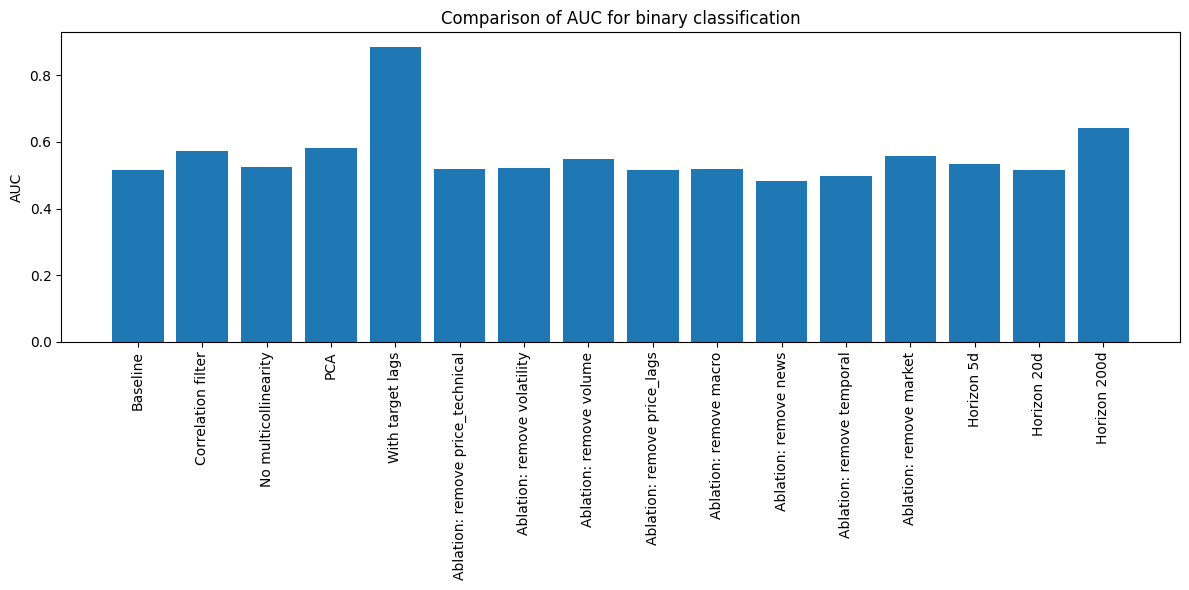

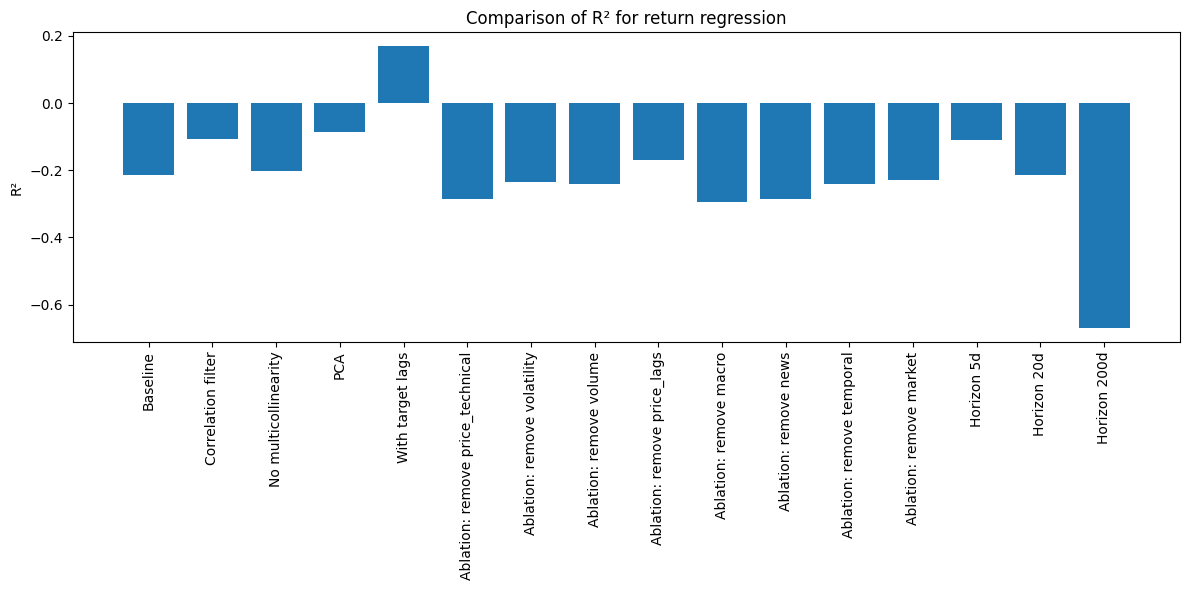

In [14]:
# Собираем результаты
summary_binary = {
    'Baseline': baseline_binary,
    'Correlation filter': corr_binary,
    'No multicollinearity': multicoll_binary,
    'PCA': pca_binary,
    'With target lags': lag_binary,
}
# Добавляем абляцию
for group, res in ablation_results_binary.items():
    summary_binary[f'Ablation: remove {group}'] = res

# Горизонты
for h, res in horizon_results_binary.items():
    summary_binary[f'Horizon {h}d'] = res

df_summary_binary = pd.DataFrame(summary_binary).T
df_summary_binary = df_summary_binary.round(4)
df_summary_binary.to_csv(ARTIFACTS_DIR / "summary_binary.csv")
print("Binary classification results:\n", df_summary_binary)

# Для регрессии
summary_return = {
    'Baseline': baseline_return,
    'Correlation filter': corr_return,
    'No multicollinearity': multicoll_return,
    'PCA': pca_return,
    'With target lags': lag_return,
}
for group, res in ablation_results_return.items():
    summary_return[f'Ablation: remove {group}'] = res
for h, res in horizon_results_return.items():
    summary_return[f'Horizon {h}d'] = res

df_summary_return = pd.DataFrame(summary_return).T
df_summary_return = df_summary_return.round(4)
df_summary_return.to_csv(ARTIFACTS_DIR / "summary_return.csv")
print("\nRegression results:\n", df_summary_return)

# Графики
plt.figure(figsize=(12,6))
auc_vals = df_summary_binary['auc'].dropna()
plt.bar(auc_vals.index, auc_vals.values)
plt.xticks(rotation=90)
plt.ylabel('AUC')
plt.title('Comparison of AUC for binary classification')
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "auc_comparison.png", dpi=150)
plt.show()

plt.figure(figsize=(12,6))
r2_vals = df_summary_return['r2'].dropna()
plt.bar(r2_vals.index, r2_vals.values)
plt.xticks(rotation=90)
plt.ylabel('R²')
plt.title('Comparison of R² for return regression')
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "r2_comparison.png", dpi=150)
plt.show()